Iteration 1/20
  m change: inf
Iteration 2/20
  m change: inf
Iteration 3/20


/home/skk/anaconda3/lib/python3.8/site-packages/scipy/integrate/_ivp/common.py:114: RuntimeWarning: invalid value encountered in scalar divide
  d2 = norm((f1 - f0) / scale) / h0
<ipython-input-4-b751b19b115a>:57: RuntimeWarning: overflow encountered in square
  H = 0.5 * a_opt**2 + m_current * x   # 哈密顿量示例（可自定义）
<ipython-input-4-b751b19b115a>:35: RuntimeWarning: invalid value encountered in subtract
  df[1:-1] = (f[2:] - f[:-2]) / (2 * dx)
<ipython-input-4-b751b19b115a>:37: RuntimeWarning: invalid value encountered in scalar subtract
  df[-1] = (f[-1] - f[-2]) / dx
<ipython-input-4-b751b19b115a>:43: RuntimeWarning: invalid value encountered in subtract
  d2f[1:-1] = (f[2:] - 2*f[1:-1] + f[:-2]) / (dx**2)
<ipython-input-4-b751b19b115a>:58: RuntimeWarning: invalid value encountered in add
  rhs = -H + diffusion * laplacian(u)
<ipython-input-4-b751b19b115a>:36: RuntimeWarning: invalid value encountered in scalar subtract
  df[0] = (f[1] - f[0]) / dx
<ipython-input-4-b751b19b115a>:70: Run

  m change: inf
Iteration 4/20
  m change: inf
Iteration 5/20
  m change: inf
Iteration 6/20
  m change: inf
Iteration 7/20
  m change: inf
Iteration 8/20
  m change: inf
Iteration 9/20
  m change: inf
Iteration 10/20
  m change: inf
Iteration 11/20
  m change: inf
Iteration 12/20
  m change: inf
Iteration 13/20
  m change: inf
Iteration 14/20
  m change: inf
Iteration 15/20
  m change: inf
Iteration 16/20
  m change: inf
Iteration 17/20
  m change: inf
Iteration 18/20
  m change: inf
Iteration 19/20
  m change: inf
Iteration 20/20
  m change: inf


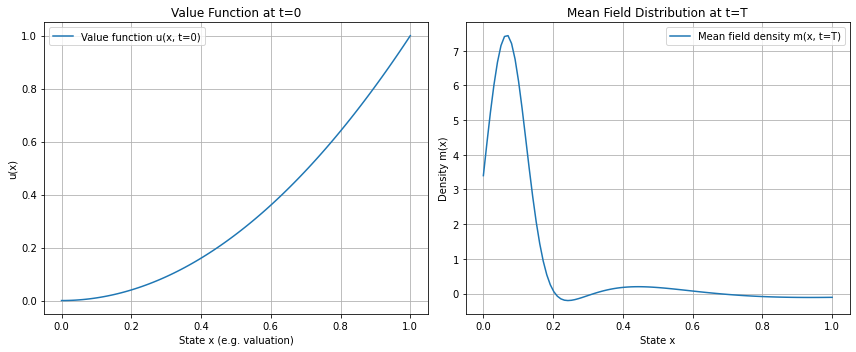

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# -------------------------------
# 参数设置
# -------------------------------
T = 1.0          # 时间终点（从 t=0 到 t=T）
Nx = 100         # 状态空间网格点数
x = np.linspace(0, 1, Nx)      # 状态空间 [0,1]，代表估值或类型
dx = x[1] - x[0]

# 初始平均场分布（假设初始代理类型服从某种分布）
m0 = np.exp(- (x - 0.5)**2 / 0.05)   # 高斯型，集中在中间
m0 = m0 / np.sum(m0) * (1 / dx)      # 归一化成密度

# 终端价值函数（t=T 时的边界条件，例如二次成本）
u_terminal = x**2                    # 示例：u(x,T) = x²

# 扩散系数（随机性强度）
sigma = 0.1
diffusion = (sigma**2) / 2

# 时间步长（用于简单显式方案，这里我们用它来近似）
dt = 0.005
Nt = int(T / dt) + 1
times = np.linspace(0, T, Nt)

# -------------------------------
# 辅助函数：计算梯度与二阶导（中心差分）
# -------------------------------
def gradient(f):
    """中心差分计算一阶导"""
    df = np.zeros_like(f)
    df[1:-1] = (f[2:] - f[:-2]) / (2 * dx)
    df[0] = (f[1] - f[0]) / dx
    df[-1] = (f[-1] - f[-2]) / dx
    return df

def laplacian(f):
    """中心差分计算二阶导"""
    d2f = np.zeros_like(f)
    d2f[1:-1] = (f[2:] - 2*f[1:-1] + f[:-2]) / (dx**2)
    d2f[0] = d2f[1]
    d2f[-1] = d2f[-2]
    return d2f

# -------------------------------
# 简化 HJB 方程（后向求解 u）
# 这里假设哈密顿 H = a²/2 + m * x  （简单交互项）
# 最优控制 a* = - ∇u
# -------------------------------
def hjb_rhs(t, u_flat, m_current):
    u = u_flat.reshape(-1)
    grad_u = gradient(u)
    a_opt = -grad_u                  # 最优出价/控制
    H = 0.5 * a_opt**2 + m_current * x   # 哈密顿量示例（可自定义）
    rhs = -H + diffusion * laplacian(u)
    return rhs

# -------------------------------
# FP 方程（前向演化 m）
# -------------------------------
def fp_rhs(t, m_flat, u_current):
    m = m_flat.reshape(-1)
    grad_u = gradient(u_current)
    v_star = -grad_u                 # 最优速度
    flux = m * v_star
    div_flux = gradient(flux)        # 注意符号
    rhs = -div_flux + diffusion * laplacian(m)
    return rhs

# -------------------------------
# 迭代求解平均场均衡（简单 Picard 迭代）
# -------------------------------
u = u_terminal.copy()          # 初始猜测：u(t=0) ≈ u_terminal
m = m0.copy()

n_iterations = 20              # 外层迭代次数（通常10-50次收敛）
u_history = []
m_history = []

for it in range(n_iterations):
    print(f"Iteration {it+1}/{n_iterations}")
    
    # 1. 后向求解 HJB（从 t=T 到 t=0）
    sol_hjb = solve_ivp(
        fun=lambda t, y: hjb_rhs(t, y, m),
        t_span=[T, 0],
        y0=u_terminal,
        method='RK45',
        rtol=1e-4,
        atol=1e-6
    )
    u = sol_hjb.y[:, -1]   # t=0 时的 u 值
    
    # 2. 前向求解 FP（从 t=0 到 t=T）
    sol_fp = solve_ivp(
        fun=lambda t, y: fp_rhs(t, y, u),
        t_span=[0, T],
        y0=m0,
        method='RK45',
        rtol=1e-4,
        atol=1e-6
    )
    m_new = sol_fp.y[:, -1]   # t=T 时的 m 值
    
    # 可选：检查收敛（这里简单用 L2 范数）
    diff = np.linalg.norm(m_new - m)
    print(f"  m change: {diff:.6e}")
    m = m_new
    
    u_history.append(u.copy())
    m_history.append(m.copy())
    
    if diff < 1e-5:
        print("Converged!")
        break

# -------------------------------
# 可视化结果
# -------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x, u, label='Value function u(x, t=0)')
plt.xlabel('State x (e.g. valuation)')
plt.ylabel('u(x)')
plt.title('Value Function at t=0')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x, m, label='Mean field density m(x, t=T)')
plt.xlabel('State x')
plt.ylabel('Density m(x)')
plt.title('Mean Field Distribution at t=T')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
import numpy as np

# 实现 Algorithm 1: Privacy Auction Algorithm (PA)
# 假设: 隐私成本 c(v, eps) = v * eps (线性成本)
# 噪声: 使用高斯机制添加噪声到数据 D (简化 D 为向量)
# 输入: v (隐私估值数组), D (数据数组, 每个参与者一个向量), B (预算)

def privacy_auction(v, D, B):
    n = len(v)
    # 步骤 2: 排序 v (假设 v 已排序为 v1 <= v2 <= ... <= vn)
    sorted_idx = np.argsort(v)
    v_sorted = v[sorted_idx]
    D_sorted = D[sorted_idx]  # 相应排序 D
    
    # 步骤 3: 找最大 k 满足 c(vk, 1/(n-k)) <= B/k
    # 这里 c(vk, eps) = vk * eps, eps = 1/(n-k)
    k_max = 0
    for k in range(1, n):  # 避免 k=n, 除零
        eps = 1 / (n - k)
        cost = v_sorted[k-1] * eps
        if cost <= B / k:
            k_max = k
        else:
            break
    k = k_max
    
    if k == 0:
        return np.zeros_like(D), np.zeros(n)  # 无选中
    
    # 步骤 4: 计算 D' = Di + N(0, Delta^2 * sigma^2)
    # 假设敏感度 Delta = 1 (简化), sigma = 1 / eps (粗略高斯机制)
    D_prime = np.zeros_like(D)
    eps = 1 / (n - k)
    sigma = 1 / eps  # 简化
    for i in range(k):
        noise = np.random.normal(0, sigma ** 2, D_sorted[i].shape)
        D_prime[sorted_idx[i]] = D_sorted[i] + noise
    
    # 支付: i > k, pi=0; i <=k, pi = min(B/k, c(v_{k+1}, 1/(n-k)))
    vk1 = v_sorted[k] if k < n-1 else v_sorted[-1]  # 如果 k=n-1, 用最后一个
    c_vk1 = vk1 * eps
    p_val = min(B / k, c_vk1)
    
    p = np.zeros(n)
    for i in range(k):
        p[sorted_idx[i]] = p_val
    
    return D_prime, p

# 测试: 模拟 N=10 参与者
N = 10
v = np.random.uniform(1, 10, N)  # 随机估值
D = np.random.normal(0, 1, (N, 5))  # 每个参与者 5维数据
B = 20  # 预算

D_prime, p = privacy_auction(v, D, B)

print("隐私估值 v:", v)
print("选中 k:", np.sum(p > 0))
print("支付 p:", p)
print("原始数据 D 第一行:", D[0])
print("加噪数据 D' 第一行 (如果选中):", D_prime[0])

隐私估值 v: [1.85356764 9.17034069 8.4313051  5.34088458 9.54913978 2.31084244
 4.02432726 3.08888972 8.35398474 7.7555347 ]
选中 k: 7
支付 p: [2.81043503 0.         0.         2.81043503 0.         2.81043503
 2.81043503 2.81043503 2.81043503 2.81043503]
原始数据 D 第一行: [-1.63063566 -1.20616005  1.33395613  0.06965173  1.83997232]
加噪数据 D' 第一行 (如果选中): [11.71950985 20.39690548 10.70234633 -0.36042785  1.97544052]


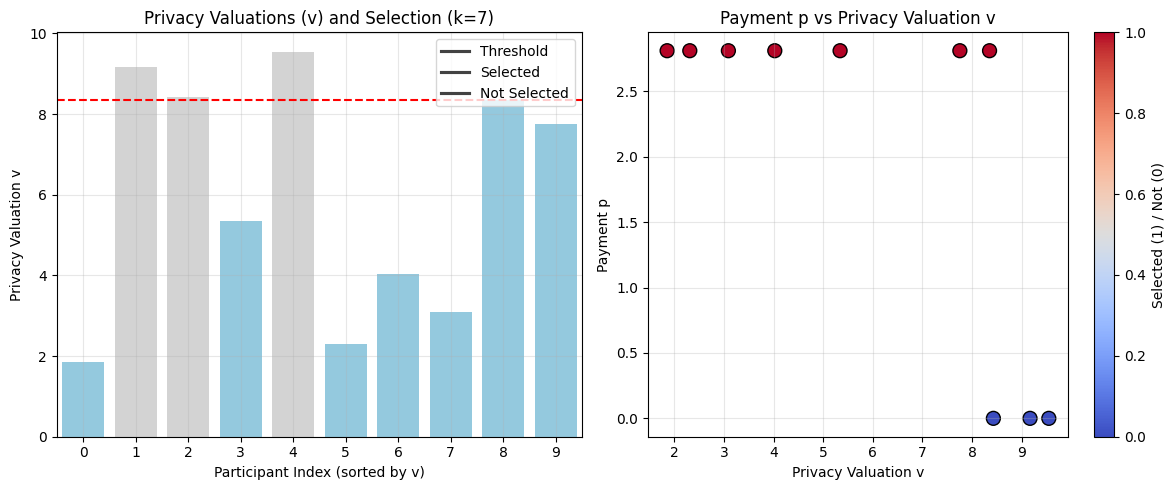

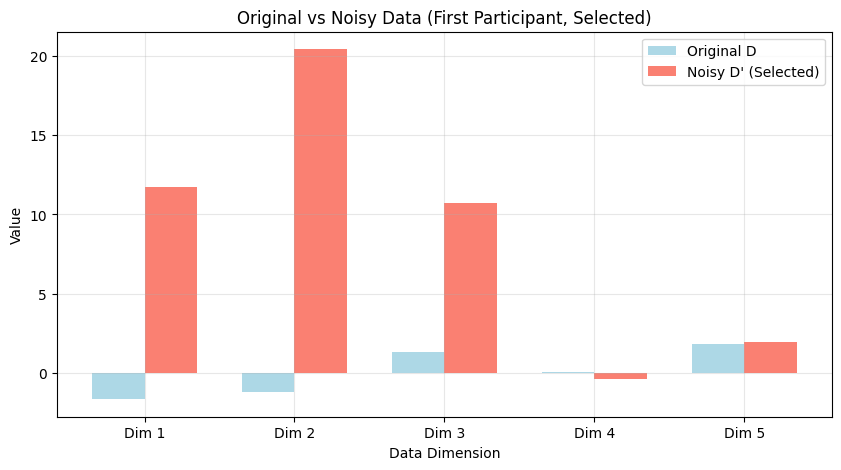

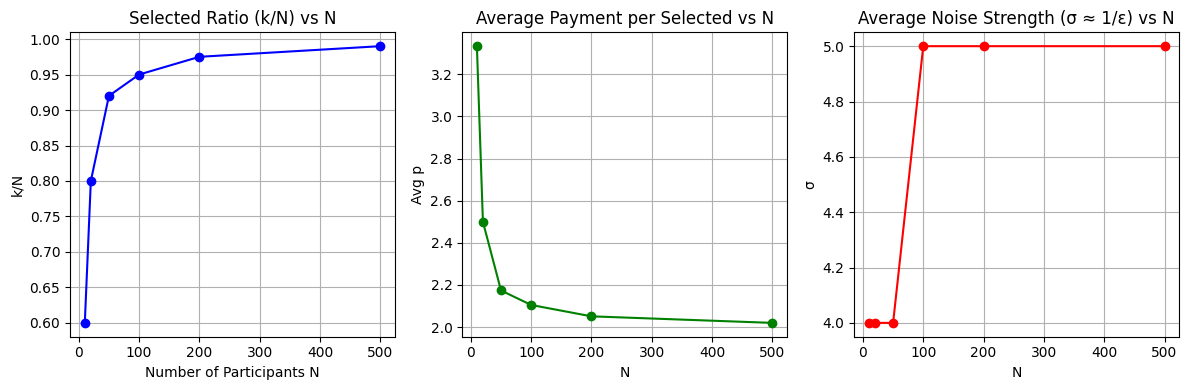

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------- 您提供的结果 -------------------
v = np.array([1.85356764, 9.17034069, 8.4313051, 5.34088458, 9.54913978,
              2.31084244, 4.02432726, 3.08888972, 8.35398474, 7.7555347])
k = 7
p = np.array([2.81043503, 0., 0., 2.81043503, 0., 2.81043503,
              2.81043503, 2.81043503, 2.81043503, 2.81043503])
D_original = np.array([-1.63063566, -1.20616005, 1.33395613, 0.06965173, 1.83997232])
D_noisy = np.array([11.71950985, 20.39690548, 10.70234633, -0.36042785, 1.97544052])

N = len(v)
selected = (p > 0).astype(int)  # 1=选中, 0=未选中

# ------------------- 图1: 隐私估值分布与选中情况 -------------------
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x=np.arange(N), y=v, hue=selected, palette={0: 'lightgray', 1: 'skyblue'}, dodge=False)
plt.axhline(y=v[np.argsort(v)[k-1]], color='red', linestyle='--', label=f'Threshold v_{k} ≈ {v[np.argsort(v)[k-1]]:.2f}')
plt.title('Privacy Valuations (v) and Selection (k=7)')
plt.xlabel('Participant Index (sorted by v)')
plt.ylabel('Privacy Valuation v')
plt.legend(['Threshold', 'Selected', 'Not Selected'])
plt.grid(True, alpha=0.3)

# ------------------- 图2: 支付 p 与 v 的关系 -------------------
plt.subplot(1, 2, 2)
plt.scatter(v, p, c=selected, cmap='coolwarm', s=100, edgecolor='black')
plt.colorbar(label='Selected (1) / Not (0)')
plt.title('Payment p vs Privacy Valuation v')
plt.xlabel('Privacy Valuation v')
plt.ylabel('Payment p')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------- 图3: 原始 D vs 加噪 D' 对比 -------------------
plt.figure(figsize=(10, 5))
x = np.arange(5)
width = 0.35
plt.bar(x - width/2, D_original, width, label='Original D', color='lightblue')
plt.bar(x + width/2, D_noisy, width, label='Noisy D\' (Selected)', color='salmon')
plt.title('Original vs Noisy Data (First Participant, Selected)')
plt.xlabel('Data Dimension')
plt.ylabel('Value')
plt.xticks(x, [f'Dim {i+1}' for i in range(5)])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ------------------- 图4: 多组模拟趋势（示例：N 变化对 k/N 和平均 p 的影响） -------------------
# 为了展示趋势，我们模拟多组 N
Ns = [10, 20, 50, 100, 200, 500]
k_ratios = []
avg_payments = []
avg_sigmas = []  # 噪声强度 1/eps

for n in Ns:
    v_sim = np.random.uniform(1, 10, n)
    B_sim = 20 * (n / 10)  # 预算随 N 线性增长（示例）
    sorted_v = np.sort(v_sim)
    
    k_sim = 0
    for kk in range(1, n):
        eps_sim = 1 / (n - kk)
        cost = sorted_v[kk-1] * eps_sim
        if cost <= B_sim / kk:
            k_sim = kk
        else:
            break
    
    k_ratios.append(k_sim / n)
    avg_payments.append(B_sim / k_sim if k_sim > 0 else 0)
    avg_sigmas.append(1 / (1 / (n - k_sim)) if k_sim < n else 0)  # sigma ≈ 1/eps

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(Ns, k_ratios, 'o-', color='blue')
plt.title('Selected Ratio (k/N) vs N')
plt.xlabel('Number of Participants N')
plt.ylabel('k/N')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(Ns, avg_payments, 'o-', color='green')
plt.title('Average Payment per Selected vs N')
plt.xlabel('N')
plt.ylabel('Avg p')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(Ns, avg_sigmas, 'o-', color='red')
plt.title('Average Noise Strength (σ ≈ 1/ε) vs N')
plt.xlabel('N')
plt.ylabel('σ')
plt.grid(True)
plt.tight_layout()
plt.show()

Figures saved: comp_time_vs_N.png, dim_vs_N.png, k_ratio_vs_N.png


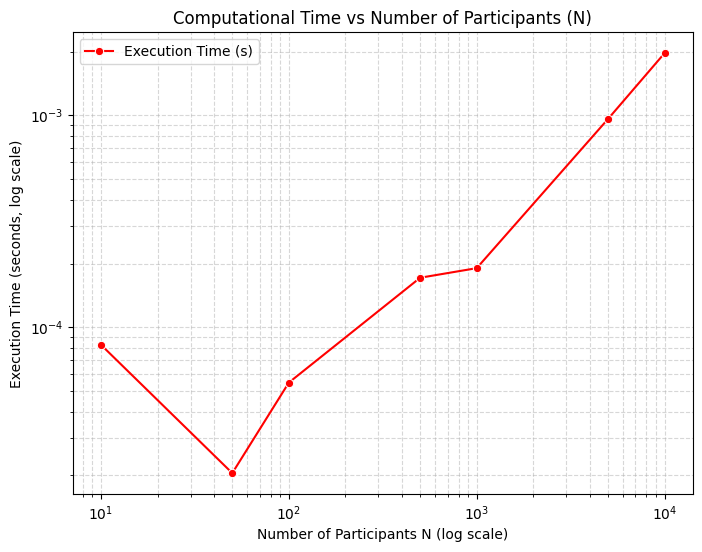

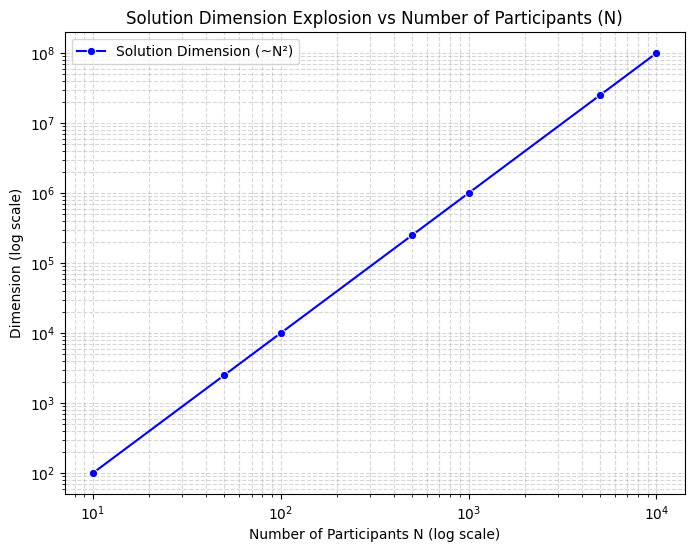

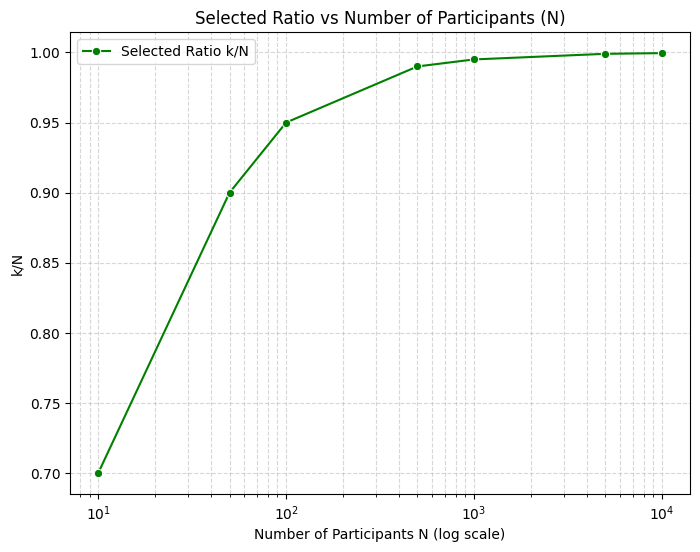

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

# 简化 Algorithm 1: Privacy Auction (跳过 D 加噪，只计算 k 和 p)
def privacy_auction(v, B):
    n = len(v)
    sorted_idx = np.argsort(v)
    v_sorted = v[sorted_idx]
    
    k_max = 0
    for k in range(1, n):
        eps = 1 / (n - k)
        cost = v_sorted[k-1] * eps
        if cost <= B / k:
            k_max = k
        else:
            break
    k = k_max
    
    if k == 0:
        return np.zeros(n), 0
    
    vk1 = v_sorted[k] if k < n-1 else v_sorted[-1]
    eps = 1 / (n - k)
    c_vk1 = vk1 * eps
    p_val = min(B / k, c_vk1)
    
    p = np.zeros(n)
    for i in range(k):
        p[sorted_idx[i]] = p_val
    
    return p, k

# 模拟不同 N 的计算时间和维度
Ns = [10, 50, 100, 500, 1000, 5000, 10000]  # 避免太大内存
times = []
k_ratios = []
dims = []

for n in Ns:
    v = np.random.uniform(1, 10, n)
    B = 20 * (n / 10)  # 预算线性增长
    
    start_time = time.time()
    p, k = privacy_auction(v, B)
    end_time = time.time()
    
    times.append(end_time - start_time)
    k_ratios.append(k / n if n > 0 else 0)
    
    # 模拟维度爆炸: Nash 求解维度 ~ n^2 (高维策略空间)
    dim = n ** 2
    dims.append(dim)

# 图1: 计算时间 vs N (展示爆炸)
plt.figure(figsize=(8, 6))
sns.lineplot(x=Ns, y=times, marker='o', color='red', label='Execution Time (s)')
plt.xscale('log')
plt.yscale('log')
plt.title('Computational Time vs Number of Participants (N)')
plt.xlabel('Number of Participants N (log scale)')
plt.ylabel('Execution Time (seconds, log scale)')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.savefig('comp_time_vs_N.png')

# 图2: 维度爆炸 vs N
plt.figure(figsize=(8, 6))
sns.lineplot(x=Ns, y=dims, marker='o', color='blue', label='Solution Dimension (~N²)')
plt.xscale('log')
plt.yscale('log')
plt.title('Solution Dimension Explosion vs Number of Participants (N)')
plt.xlabel('Number of Participants N (log scale)')
plt.ylabel('Dimension (log scale)')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.savefig('dim_vs_N.png')

# 图3: 选中比例 k/N vs N (辅助趋势)
plt.figure(figsize=(8, 6))
sns.lineplot(x=Ns, y=k_ratios, marker='o', color='green', label='Selected Ratio k/N')
plt.xscale('log')
plt.title('Selected Ratio vs Number of Participants (N)')
plt.xlabel('Number of Participants N (log scale)')
plt.ylabel('k/N')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.savefig('k_ratio_vs_N.png')

print("Figures saved: comp_time_vs_N.png, dim_vs_N.png, k_ratio_vs_N.png")